# US Retail Sales Forecasting — walkthrough

A step-by-step time-series analysis: forecast monthly US retail & food-services
sales, so a business could plan inventory and cash flow ahead of demand.

This notebook mirrors `forecasting_analysis.py` with the reasoning shown inline.
Dataset: FRED **RSXFSN** (not seasonally adjusted), 414 months, 1992–2026.

**Author:** Muhammad Nasiruddin

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 3.5)
INK, ACCENT, WARN = "#1d3557", "#2a9d8f", "#e76f51"

def mape(y, p):
    y, p = np.asarray(y), np.asarray(p)
    return float(np.mean(np.abs((y - p) / y)) * 100)

## 2. Load the data

Monthly series, indexed by date at month-start (`MS`) frequency.

In [2]:
df = pd.read_csv("data/us_retail_sales.csv", parse_dates=["observation_date"])
df = df.rename(columns={"observation_date": "date", "RSXFSN": "sales"})
s = df.set_index("date")["sales"].asfreq("MS")
print(f"{len(s)} months, {s.index.min():%Y-%m} to {s.index.max():%Y-%m}")
s.tail()

414 months, 1992-01 to 2026-06


date
2026-02-01    564663
2026-03-01    657586
2026-04-01    654070
2026-05-01    685407
2026-06-01    672368
Freq: MS, Name: sales, dtype: int64

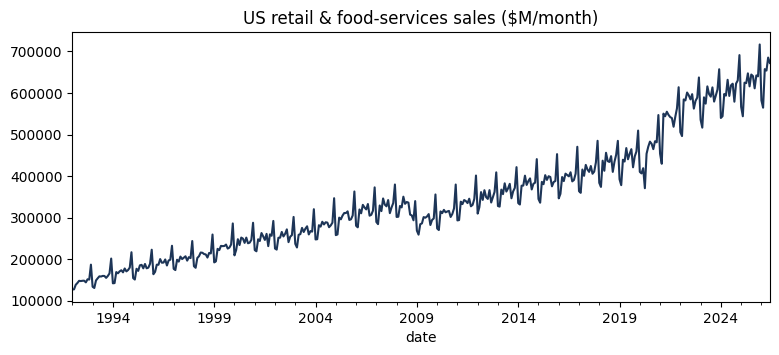

In [3]:
s.plot(color=INK, title="US retail & food-services sales ($M/month)"); plt.show()

## 3. Seasonality

The series is strongly seasonal. A multiplicative decomposition separates the
long-run **trend** from the repeating **seasonal** shape and the **residual**.

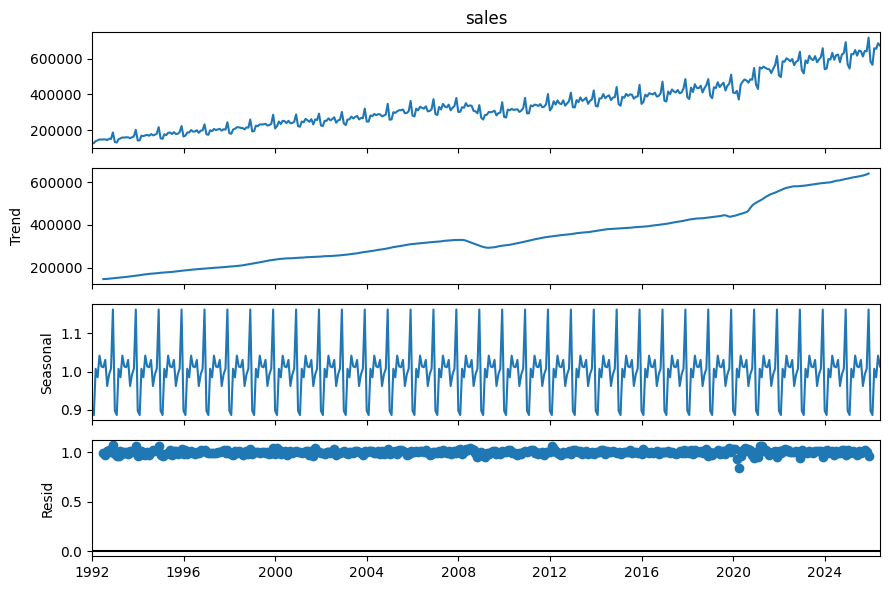

In [4]:
result = seasonal_decompose(s, model="multiplicative", period=12)
result.plot(); plt.gcf().set_size_inches(9, 6); plt.tight_layout(); plt.show()

In [5]:
seasonal = s.groupby(s.index.month).mean()
seasonal = seasonal / seasonal.mean() * 100
seasonal.round(1)

date
1      89.5
2      88.4
3     101.0
4      99.1
5     105.2
6     102.5
7     100.2
8     102.2
9      95.8
10     99.3
11    101.2
12    115.7
Name: sales, dtype: float64

December (~116% of an average month) is the clear peak; February the low.

## 4. Backtest three models

Hold out the last 24 months, train on the rest, and compare:
a seasonal-naive baseline, Holt-Winters, and SARIMA.

In [6]:
TEST = 24
train, test = s.iloc[:-TEST], s.iloc[-TEST:]

# Baseline: same month a year earlier.
ly = train.iloc[-12:].values
naive = np.array([ly[i % 12] for i in range(TEST)])

hw = ExponentialSmoothing(train, trend="add", seasonal="mul", seasonal_periods=12).fit()
hw_pred = hw.forecast(TEST).values

sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_pred = np.asarray(sarima.forecast(TEST))

pd.DataFrame([
    {"Model": n,
     "MAE": round(mean_absolute_error(test, p)),
     "RMSE": round(np.sqrt(mean_squared_error(test, p))),
     "MAPE %": round(mape(test, p), 2)}
    for n, p in [("Seasonal-naive", naive), ("Holt-Winters", hw_pred), ("SARIMA", sarima_pred)]
])

,Model,MAE,RMSE,MAPE %
0,Seasonal-naive,33829,39007,5.26
1,Holt-Winters,26911,29823,4.22
2,SARIMA,17514,20857,2.71


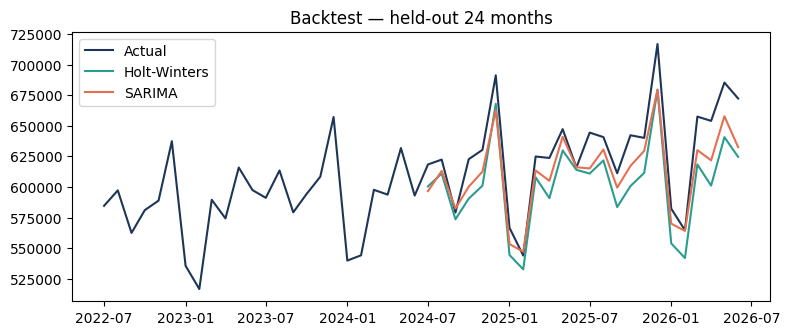

In [7]:
ctx = s.iloc[-48:]
plt.plot(ctx.index, ctx.values, color=INK, label="Actual")
plt.plot(test.index, hw_pred, color=ACCENT, label="Holt-Winters")
plt.plot(test.index, sarima_pred, color=WARN, label="SARIMA")
plt.legend(); plt.title("Backtest — held-out 24 months"); plt.show()

**SARIMA wins** (~2.7% MAPE) — it best captures both trend and seasonality.

## 5. Forecast the next 12 months

Refit SARIMA on all the data and project forward, with its 95% interval.

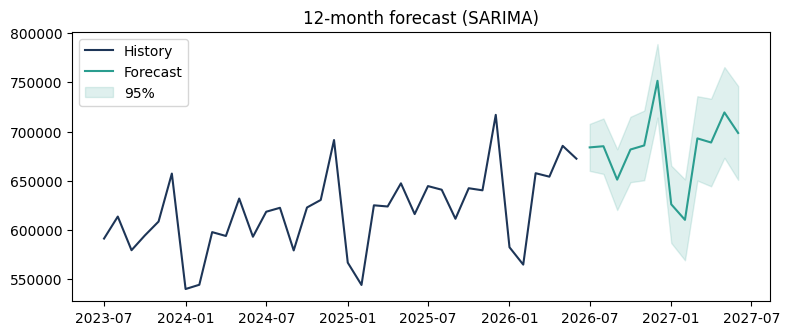

Forecast total next 12 months: $8,175B


In [8]:
model = SARIMAX(s, order=(1,1,1), seasonal_order=(1,1,1,12),
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
res = model.get_forecast(12)
fc = res.predicted_mean
ci = res.conf_int(alpha=0.05)

hist = s.iloc[-36:]
plt.plot(hist.index, hist.values, color=INK, label="History")
plt.plot(fc.index, fc.values, color=ACCENT, label="Forecast")
plt.fill_between(fc.index, ci.iloc[:,0], ci.iloc[:,1], color=ACCENT, alpha=.15, label="95%")
plt.legend(); plt.title("12-month forecast (SARIMA)"); plt.show()

print(f"Forecast total next 12 months: ${fc.sum()/1000:,.0f}B")

## 6. Cross-check with SQL

The same series can be queried with SQL. Here we load it into SQLite and compute
the seasonal index — a good habit is to confirm two tools agree.

In [9]:
import sqlite3
conn = sqlite3.connect(":memory:")
df[["date","sales"]].assign(date=df["date"].dt.strftime("%Y-%m-%d")).to_sql("retail_sales", conn, index=False)

q = '''
WITH monthly AS (
  SELECT CAST(strftime('%m', date) AS INT) AS month, AVG(sales) AS avg_sales
  FROM retail_sales GROUP BY month)
SELECT month, ROUND(avg_sales/(SELECT AVG(avg_sales) FROM monthly)*100, 1) AS seasonal_index
FROM monthly ORDER BY month;'''
pd.read_sql_query(q, conn)

,month,seasonal_index
0,1,89.5
1,2,88.4
2,3,101.0
3,4,99.1
4,5,105.2
5,6,102.5
6,7,100.2
7,8,102.2
8,9,95.8
9,10,99.3


## Takeaways

- The series has a strong, stable **December peak** (~116% of average) and a
  February trough (~88%).
- Of three models, **SARIMA** forecast the held-out period most accurately
  (~2.7% MAPE), roughly halving the naive baseline's error.
- The 12-month forecast projects continued growth with the usual holiday spike.
- pandas and SQL give the same seasonal picture — a useful consistency check.